
TFG

Este es el codigo del tfg de Borja Jimeno

In [11]:
import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
import re
import uproot




plt.rcParams['font.size'] = 18

In [12]:
def imprime_plot(e_i,e_s,tipo,print_plot=0):
    
    nombre=""

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    nombre=prin1+f'{e_i:.6f}'+"_"+f'{e_s:.6f}'+prin2+modos[tipo]

    file = uproot.open("SI_varios_intervalos.root")
    graph = file[nombre]

    
    x_aux=graph.member("fX")
    y_aux=graph.member("fY")
    
    x=[]
    y=[]

    for i in range(len(x_aux)):
        if y_aux[i]<1e-35:
            if y_aux[i]>1e-55:
                x.append(x_aux[i])
                y.append(y_aux[i])

                

    
    if print_plot==1:
            plt.figure(figsize=(14, 8))
            ax = plt.subplot()

            ax.plot(x,y)


            #ax.legend()
            ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
            ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
            ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

            ax.set_yscale("log")
            ax.set_xscale("log")

            y_sup=1e-35
            y_inf=1e-45

            ax.set_ylim(y_inf,y_sup)
            ax.set_xlim(1,1000)

            exp_min = int(np.floor(np.log10(y_inf)))   
            exp_max = int(np.ceil(np.log10(y_sup)))    
            exps = np.arange(exp_min, exp_max)     


            all_ticks = []
            for e in exps:
                decade = (np.arange(1, 10) * (10.0**e)).tolist()
                all_ticks.extend(decade)
            all_ticks = np.array(all_ticks)

            ax.set_yticks(all_ticks)                    

            ax.grid(which='both', linestyle='-', alpha=0.2)

    return x,y

def encuentra_intervalo(cadena):
    valores = re.findall(r"\d+\.\d+", cadena)
    a=np.zeros(2)
    a[0]=float(valores[0])
    a[1]=float(valores[1])
    return a

def genera_lista_modos(lista_modos):
    lista_ref=(0,1,2,3,4)
    lista_ref=np.array(lista_ref)
    if (type(lista_modos)==int):
        a=np.where(lista_ref == lista_modos,1,0)
        return a
        
    else:
        lista_modos=np.array(lista_modos)
        a=np.zeros(len(lista_ref),dtype=int)
        for i in range (len(lista_modos)):
            a+=np.where(lista_ref == lista_modos[i],1,0)
        return a


def lista_intervalo(lista_energias,lista_modos):
    
    lista_ref=genera_lista_modos(lista_modos)

    
    list_names=[]
    list_energies=[]

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    for i in range (len(lista_energias)):
            intervalo_minimo=np.zeros(3)
            if lista_ref[int(lista_energias[i][2])]>0:
                list_names.append(prin1+f'{lista_energias[i][0]:.6f}'+"_"+f'{lista_energias[i][1]:.6f}'+prin2+modos[int(lista_energias[i][2])])
                intervalo_minimo[0]=lista_energias[i][0]
                intervalo_minimo[1]=lista_energias[i][1]
                intervalo_minimo[2]=int(lista_energias[i][2])
                list_energies.append(intervalo_minimo)


    return list_names, list_energies



def carga_datos_hist(lista_energias,lista_modos):

    lista_nombres, list_energies=lista_intervalo(lista_energias,lista_modos)
    
    file = uproot.open("SI_varios_intervalos.root")
    
    datos=[]
    intervalos=[]
    resultado=[]

    for i in range(len(lista_nombres)):

        valores=list_energies[i]
        nombre=lista_nombres[i]

        graph = file[nombre]
        aux=np.ones((3,len(graph.member("fX"))))
        aux[0]=graph.member("fX")
        aux[1]=graph.member("fY")

        for j in range (len(aux[0])):
            if aux[1][j]>1e-35:
                aux[2][j]=0
            if aux[1][j]<1e-55:
                aux[2][j]=0


        datos.append(aux)
        intervalos.append(valores)
    
    resultado.append(datos)
    resultado.append(intervalos)
    return resultado

def minimiza_lista_datos(lista_datos):
    
    longitud=len(lista_datos[0][0][0])
    masas=[]
    sigmas=[]
    int_min=[]

   

    for i in range (longitud):
        sigma_aux=1
        masa_ref=0
        intervalo_minimo=np.zeros(3)
        for j in range (len(lista_datos[1])):
            a=0
            if(lista_datos[0][j][2][i]>0):
                masa_ref=1
                if(lista_datos[0][j][1][i]<sigma_aux):
                    sigma_aux=lista_datos[0][j][1][i]
                    intervalo_minimo[0]=lista_datos[1][j][0]
                    intervalo_minimo[1]=lista_datos[1][j][1]
                    intervalo_minimo[2]=lista_datos[1][j][2]
    
        if masa_ref==1:
            sigmas.append(sigma_aux)
            masas.append(lista_datos[0][0][0][i])
            int_min.append(intervalo_minimo)

    return masas,sigmas,int_min


[4.719879529820819e-39, 1.7713667626632187e-39, 1.2544731755374666e-39, 9.181792544982314e-40, 7.008767061071195e-40, 4.424349873805715e-40, 3.6185233253168997e-40, 3.0332495318527937e-40, 2.542346864806681e-40, 1.8915883846901964e-40, 1.6762239797792556e-40, 1.489891473120413e-40, 1.3304714574013751e-40, 1.092453145655981e-40, 1.0057925650396192e-40, 9.226614237062265e-41, 8.639122524869727e-41, 7.592253750307407e-41, 7.14518143376162e-41, 6.776028074210366e-41, 6.418331263951675e-41, 5.886963387570689e-41, 4.319189769113335e-41, 3.6033825833661164e-41, 2.3605478409673416e-41, 1.460725075173522e-41, 1.206819977535505e-41, 7.635308654179858e-42, 5.207991297960186e-42, 2.973579274704686e-42, 2.4319855175577185e-42, 2.0657242972296376e-42, 1.819664835030998e-42, 1.4864742335879852e-42, 1.377495334061065e-42, 1.2977675588496968e-42, 1.2321580702867893e-42, 1.140955280865168e-42, 1.117442493165741e-42, 1.0888804999352885e-42, 1.0717374386560132e-42, 1.0452922723047465e-42, 1.03714434935745

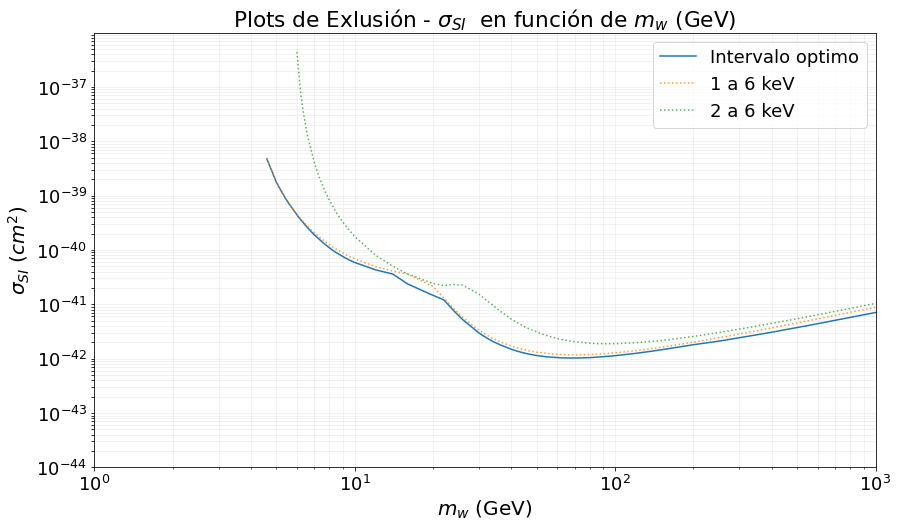

In [13]:
lista_energias = np.loadtxt('list_energies_sel.txt')
lista_modos=(3)

lista_nombres=lista_intervalo(lista_energias,lista_modos)
lista_datos=carga_datos_hist(lista_energias,lista_modos)


masas,sigmas,intervalo_minimo=minimiza_lista_datos(lista_datos)

x_1,y_1=imprime_plot(1,6,3)
x_2,y_2=imprime_plot(2,6,3)

plt.figure(figsize=(14, 8))
ax = plt.subplot()

ax.plot(masas,sigmas,label="Intervalo optimo")

ax.plot(x_1,y_1,label="1 a 6 keV",linestyle=":",alpha=0.8)

ax.plot(x_2,y_2,label="2 a 6 keV",linestyle=":",alpha=0.8)


ax.legend()
ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-36
y_inf=1e-44

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

sigma_variable_2keV=sigmas

print(sigmas)


In [14]:
print(intervalo_minimo)

[array([1. , 2.5, 3. ]), array([1. , 2.5, 3. ]), array([1., 3., 3.]), array([1., 3., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([2.5, 4. , 3. ]), array([2.5, 4. , 3. ]), array([2.5, 4. , 3. ]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]), array([1., 2., 3.]

In [18]:
m=masas
s=sigmas

fichero = open("SI_ANAIS_BIEN.txt", 'w')
# Guardamos la lista en el fichero
for i in range(len(m)):
    fichero.write(f"{m[i]} \t {s[i]} \n")

# Cerramos el fichero
fichero.close()

In [16]:
for i in range (len(masas)):
    print(f'Mass: {masas[i]:.1f} GeV - Minimum Exlussion Interval:  ({intervalo_minimo[i][0]} - {intervalo_minimo[i][1]}) keV - Tipo: {int(intervalo_minimo[i][2])}')
    


Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV - Tipo: 3
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV - Tipo: 3
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 3.0) keV - Tipo: 3
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 3.0) keV - Tipo: 3
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 6.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 6.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 6.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 6.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 7.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 7.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 7.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 7.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 8.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV - Tipo: 3
Mass: 